In [2]:
import warnings
warnings.filterwarnings('ignore')

## Логистическая регрессия

Источник данных: https://www.kaggle.com/datasets/jsphyg/weather-dataset-rattle-package

Набор данных включает в себя примерно 10 лет ежедневных метеорологических наблюдений из многочисленных мест по всей Австралии.

#### Задача: предсказать, пойдет ли дождь на следующий день при заданных метеорологических параметрах.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Исходные данные

In [4]:
df = pd.read_csv("data/weatherAUS.csv")
df.sample(5)

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
132497,2016-01-09,Hobart,14.5,28.2,0.0,7.6,11.9,ESE,46.0,NW,...,33.0,21.0,1015.6,1014.3,1.0,2.0,21.8,26.5,No,No
29831,2016-07-16,Richmond,1.5,17.4,0.0,NaN,NaN,SSW,13.0,SE,...,94.0,56.0,1033.8,1030.3,8.0,8.0,6.1,16.5,No,No
53348,2012-07-09,MountGinini,-1.8,5.6,0.6,NaN,NaN,WNW,33.0,WNW,...,95.0,82.0,NaN,NaN,NaN,NaN,0.4,3.5,No,No
117088,2016-01-02,PearceRAAF,22.3,38.7,0.0,NaN,11.4,E,63.0,ESE,...,40.0,22.0,1010.9,1006.8,NaN,NaN,27.5,37.1,No,No
62309,2012-03-03,Sale,15.6,18.0,0.0,6.4,0.0,ENE,57.0,ENE,...,69.0,80.0,1017.4,1013.3,8.0,8.0,17.3,17.9,No,Yes


Пропуски

In [5]:
df.isna().sum()

Date                 0
Location             0
MinTemp           1485
MaxTemp           1261
Rainfall          3261
Evaporation      62790
Sunshine         69835
WindGustDir      10326
WindGustSpeed    10263
WindDir9am       10566
WindDir3pm        4228
WindSpeed9am      1767
WindSpeed3pm      3062
Humidity9am       2654
Humidity3pm       4507
Pressure9am      15065
Pressure3pm      15028
Cloud9am         55888
Cloud3pm         59358
Temp9am           1767
Temp3pm           3609
RainToday         3261
RainTomorrow      3267
dtype: int64

Так как данных достаточно много, удалим все наблюдения с пропусками. Заполнение большого числа пропусков средними/медианными значениями может исказить влияние природных факторов на появление дождя.

Удалим повторяющиеся наблюдения, если есть.

In [6]:
df = df.dropna()
df.drop_duplicates()
obj, factors = df.shape
print(f"Кол-во наблюдений:{obj}\nКол-во признаков:{factors}")

Кол-во наблюдений:56420
Кол-во признаков:23


Базовые статистики данных

In [7]:
df.describe()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm
count,56420.000000,56420.000000,56420.000000,56420.000000,56420.000000,56420.000000,56420.000000,56420.000000,56420.000000,56420.000000,56420.000000,56420.000000,56420.000000,56420.000000,56420.000000,56420.000000
mean,13.464770,24.219206,2.130397,5.503135,7.735626,40.877366,15.667228,19.786778,65.874123,49.601985,1017.239505,1014.795580,4.241705,4.326515,18.204961,22.710333
std,6.416689,6.970676,7.014822,3.696282,3.758153,13.335232,8.317005,8.510180,18.513289,20.197040,6.909357,6.870892,2.797162,2.647251,6.567991,6.836543
min,-6.700000,4.100000,0.000000,0.000000,0.000000,9.000000,2.000000,2.000000,0.000000,0.000000,980.500000,977.100000,0.000000,0.000000,-0.700000,3.700000
25%,8.600000,18.700000,0.000000,2.800000,5.000000,31.000000,9.000000,13.000000,55.000000,35.000000,1012.700000,1010.100000,1.000000,2.000000,13.100000,17.400000
50%,13.200000,23.900000,0.000000,5.000000,8.600000,39.000000,15.000000,19.000000,67.000000,50.000000,1017.200000,1014.700000,5.000000,5.000000,17.800000,22.400000
75%,18.400000,29.700000,0.600000,7.400000,10.700000,48.000000,20.000000,26.000000,79.000000,63.000000,1021.800000,1019.400000,7.000000,7.000000,23.300000,27.900000
max,31.400000,48.100000,206.200000,81.200000,14.500000,124.000000,67.000000,76.000000,100.000000,100.000000,1040.400000,1038.900000,8.000000,9.000000,39.400000,46.100000


In [8]:
df.describe(include=["O"])

,Date,Location,WindGustDir,WindDir9am,WindDir3pm,RainToday,RainTomorrow
count,56420,56420,56420,56420,56420,56420,56420
unique,3416,26,16,16,16,2,2
top,2009-01-04,Darwin,E,N,SE,No,No
freq,25,3062,4516,4967,4153,43958,43993


До начала исследования значимости признаков заменим дату на номер месяца, так как появление дождей может зависеть именно от месяца, а не от года или дня.

Уменьшим количество зафиксированных направлений ветра с 16 до 4, оставив основные (преобразование Северо-северо-восток к северу и т.п.)

Локации можно заменить географическими координатами или обозначением района Австралии (восточное побережье, пустыня и т.п.), но в рамках работы будут рассмотрены только метеорологические показатели.

In [9]:
df["Month"] = df["Date"].str[5:7].astype(int)
df = df.drop(columns=["Date", "Location"])
for col in df.columns:
    if "Dir" in col:
        df[col] = df[col].str[0]

Замена Yes/No на 0/1:

In [10]:
df["RainToday"] = (df["RainToday"] == "Yes").astype(int)
df["RainTomorrow"] = (df["RainTomorrow"] == "Yes").astype(int)

Категориальные признаки закодируем, числовые стандартизируем

In [11]:
X = df.drop(columns=["RainTomorrow"])
y = df["RainTomorrow"]

In [12]:
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_transformer

numeric_features = X.select_dtypes(include="number").columns
cat_features = X.select_dtypes(include="object").columns


pipeline = make_pipeline(
    make_column_transformer(
        (MinMaxScaler(), numeric_features),
        (OneHotEncoder(sparse_output=False, handle_unknown="ignore"), cat_features),
        verbose_feature_names_out=False,
        remainder="passthrough"
    )
)
X_transformed = pipeline.fit_transform(X)
X_transformed = pd.DataFrame(X_transformed, columns=pipeline.get_feature_names_out())

In [13]:
print(f"Кол-во признаков: {X_transformed.shape[1]}")
X_transformed.head(3)

Кол-во признаков: 30


,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,...,WindGustDir_S,WindGustDir_W,WindDir9am_E,WindDir9am_N,WindDir9am_S,WindDir9am_W,WindDir3pm_E,WindDir3pm_N,WindDir3pm_S,WindDir3pm_W
0,0.645669,0.706818,0.0,0.147783,0.848276,0.339130,0.061538,0.243243,0.20,0.13,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.658793,0.563636,0.0,0.182266,0.896552,0.243478,0.261538,0.229730,0.30,0.08,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,0.685039,0.761364,0.0,0.133005,0.731034,0.321739,0.430769,0.175676,0.42,0.22,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0


#### Исследование данных

Рассмотрим соотношение предсказываемых классов, а также корреляции признаков между собой и с целевой переменной

Text(0.5, 1.0, '0 - Дождя завтра не будет\n1 - Дождь будет')

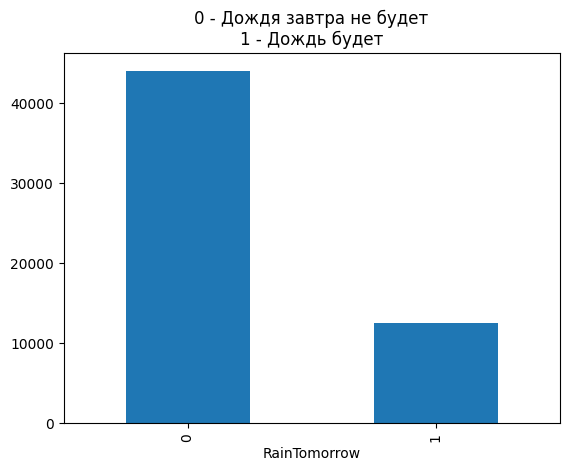

In [14]:
y.value_counts().plot.bar()
plt.title("0 - Дождя завтра не будет\n1 - Дождь будет")

In [15]:
corr_matr = X_transformed.corr()

upper = corr_matr.where(
    np.triu(np.ones(corr_matr.shape), k=1).astype(bool)
)

to_drop = []
correlation_info = {}

for col in upper.columns:
    high_corr = upper.index[upper[col] > 0.9].tolist()
    
    if high_corr:
        to_drop.append(col)
        correlation_info[col] = [(row, upper.loc[row, col]) for row in high_corr]

for feature in to_drop:
    for related, corr in correlation_info[feature]:
        print(f"{feature} коррелирует с {related}: {corr:.3f}")

X_transformed = X_transformed.drop(columns=to_drop)


Pressure3pm коррелирует с Pressure9am: 0.962
Temp9am коррелирует с MinTemp: 0.906
Temp3pm коррелирует с MaxTemp: 0.985


Стратифицированное разделение выборки на обучающую и тренировочную в соотношении 75/25:

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_transformed, y, test_size=0.25, stratify=y)

X_train = X_train.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)

X_test = X_test.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

=============logit=============
          Признак  Коэффициент        p-value
0           const    -3.994906   1.398322e-86
1         MinTemp    -1.141050   4.838832e-07
2         MaxTemp     3.030716   3.228230e-30
3        Rainfall     2.265441   2.541677e-06
4     Evaporation    -1.588613   2.678355e-03
5        Sunshine    -2.258448  1.458411e-110
6   WindGustSpeed     6.399532  3.294597e-212
7    WindSpeed9am    -1.106582   4.579578e-13
8    WindSpeed3pm    -1.600361   3.003799e-18
9     Humidity3pm     5.791831   0.000000e+00
10    Pressure9am    -2.630990   1.397794e-57
11       Cloud9am    -0.165539   1.356795e-02
12       Cloud3pm     0.969725   1.867890e-30
13      RainToday     0.361771   4.515665e-19
14          Month     0.318886   2.814750e-10
15  WindGustDir_E    -0.153120   4.092129e-03
16  WindGustDir_N    -0.153383   1.049157e-03
17   WindDir9am_E    -0.153421   3.649890e-03
18   WindDir9am_S    -0.314421   4.276750e-11
19   WindDir9am_W    -0.160912   7.459940e-04
20

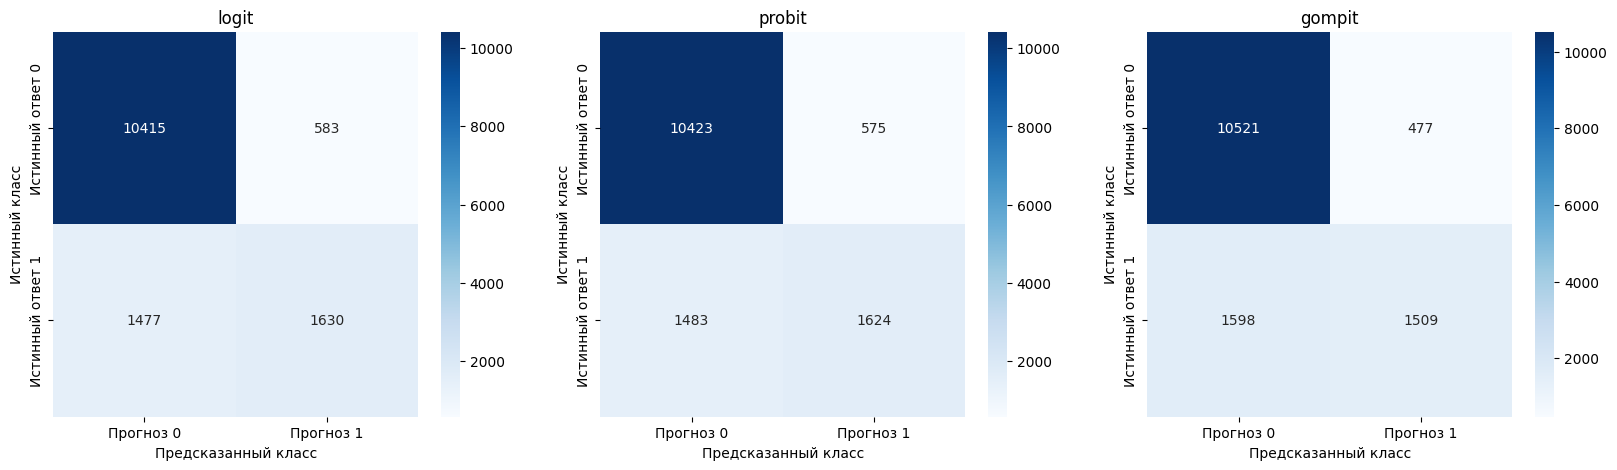

In [17]:
import statsmodels.api as sm
from sklearn.metrics import roc_auc_score, accuracy_score, confusion_matrix, roc_curve

X_train_const = sm.add_constant(X_train)
X_test_const = sm.add_constant(X_test)

def stepwise_regression(X, y, model_type="logit", alpha=0.05):
    X_curr = X.copy()
    
    while True:
        if model_type == "logit":
            model = sm.Logit(y, X_curr).fit(disp=0)
        elif model_type == "probit":
            model = sm.Probit(y, X_curr).fit(disp=0)
        elif model_type == "gompit":
            model = sm.GLM(y, X_curr, family=sm.families.Binomial(link=sm.families.links.cloglog())).fit()
        
        pvalues = model.pvalues.drop("const", errors="ignore")
        max_p = pvalues.max()
        
        if max_p > alpha:
            worst_feature = pvalues.idxmax()
            X_curr = X_curr.drop(columns=[worst_feature])
        else:
            break
    
    return model, X_curr

results = {}
i = 0

fig, axe = plt.subplots(1, 3, figsize=(20, 5))

for model_type in ["logit", "probit", "gompit"]:
    model, X_selected = stepwise_regression(X_train_const, y_train, model_type)
    
    X_test_sel = X_test_const[X_selected.columns]
    y_pred_prob = model.predict(X_test_sel)
    y_pred = (y_pred_prob > 0.5).astype(int)
    
    auc = roc_auc_score(y_test, y_pred_prob)
    gini = 2 * auc - 1
    acc = accuracy_score(y_test, y_pred)
    
    conf_matr = confusion_matrix(y_test, y_pred)
    sns.heatmap(conf_matr, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Прогноз 0", "Прогноз 1"],
            yticklabels=["Истинный ответ 0", "Истинный ответ 1"], ax=axe[i])
    
    axe[i].set_xlabel("Предсказанный класс")
    axe[i].set_ylabel("Истинный класс")
    axe[i].set_title(model_type)
    i += 1
    tn, fp, fn, tp = conf_matr.ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan
    tpr = sensitivity
    fpr = 1 - specificity
    
    fpr_curve, tpr_curve, thresholds = roc_curve(y_test, y_pred_prob)
    
    coef_table = pd.DataFrame({
        "Признак": X_selected.columns,
        "Коэффициент": model.params,
        "p-value": model.pvalues
    }).reset_index(drop=True)
    print(f"============={model_type}=============")
    print(coef_table)
    print()

    mfx = model.get_margeff(at='mean')
    mfx_summary = mfx.summary()
    print(mfx_summary)
    print()

    results[model_type] = {
        "model": model,
        "features": X_selected.columns,
        "AIC": model.aic,
        "BIC": model.bic if hasattr(model, "bic") else None,
        "Accuracy": acc,
        "Sensitivity (TPR)": sensitivity,
        "Specificity (TNR)": specificity,
        "FPR": fpr,
        "ROC points": (fpr_curve, tpr_curve),
        "AUC": auc,
        "Gini": gini
    }

comparison = pd.DataFrame({
    k: {
        "AIC": v["AIC"],
        "BIC": v["BIC"],
        "Accuracy": v["Accuracy"],
        "Sensitivity (TPR)": v["Sensitivity (TPR)"],
        "Specificity (TNR)": v["Specificity (TNR)"],
        "FPR": v["FPR"],
        "AUC": v["AUC"],
        "Gini": v["Gini"]
    }
    for k, v in results.items()
}).T

print("\nСравнение моделей:")

best_model_type = comparison["AIC"].idxmin()
best_model = results[best_model_type]["model"]
best_features = results[best_model_type]["features"]

print(f"\nЛучшая модель: {best_model_type}")
print("Признаки:", list(best_features))

Модели в два раза чаще ошибаются на истинных положительных метках классов.

In [18]:
comparison

,AIC,BIC,Accuracy,Sensitivity (TPR),Specificity (TNR),FPR,AUC,Gini
logit,28609.710324,28808.726953,0.853952,0.524622,0.946990,0.053010,0.882531,0.765061
probit,28563.879802,28762.896431,0.854094,0.522691,0.947718,0.052282,0.882887,0.765775
gompit,28925.708138,-421661.260966,0.852889,0.485678,0.956628,0.043372,0.880703,0.761406


#### Выводы по маржинальным коэффициентам

- Наиболее сильное положительное влияние оказывают:

WindGustSpeed (скорость порывов ветра): увеличение на 1 единицу повышает вероятность дождя примерно на 0.69 (logit), 0.77 (probit) и 0.49 (gompit);  
Humidity3pm (влажность в 15:00): рост на 1 увеличивает вероятность на 0.62–0.70;  
MaxTemp (максимальная температура): увеличение на 1 повышает вероятность на 0.35–0.41;  
Rainfall (осадки сегодня): увеличение на 1 приводит к росту вероятности на 0.26–0.32.  

- Наиболее выраженное отрицательное влияние:

Sunshine (солнечность): увеличение на 1 снижает вероятность дождя на 0.25–0.30;  
Pressure9am (давление): рост на 1 уменьшает вероятность на 0.29–0.34;  
Evaporation (испарение): увеличение на 1 снижает вероятность на 0.20–0.23;  
WindSpeed3pm (скорость ветра днём): увеличение на 1 снижает вероятность на 0.19–0.23.  

- Факторы умеренного влияния:

MinTemp (минимальная температура): снижение вероятности на 0.15–0.19;  
Cloud3pm (облачность): увеличение вероятности на 0.10–0.11;  
RainToday (дождь сегодня): увеличение вероятности примерно на 0.04–0.05;  
Month (месяц): слабый положительный эффект около 0.02–0.03.  

Категориальные признаки направления ветра в среднем уменьшают вероятность дождя на 0.01–0.05 относительно базовой категории.

- По информационным критериям наилучшую подгонку имеет probit-модель.

- По качеству классификации (AUC, Джини, Accuracy) наилучшей с небольшим отрывом является probit. При этом лучшая чувствительность (доля истинно положительных ответов) у logit, а специфичность (доля истинно отрицательных ответов) у gompit.

- Наилучшей можно назвать модель probit. Все модели достаточно точно с показателем TNR > 93% выделяют отрицательные ответы (Дождя не будет), но при этом плохо предсказывают положительные (Дождь будет). Это может быть связано с дисбалансом классов в предсказываемой переменной.

По маржинальным коэффициентам модели probit самыми важными признаками скорого дождя являются:

- Скорость самого сильного порыва ветра (0.787) -- Более сильные порывы ветра значительно увеличивают вероятность дождя на 78.7%

- Максимальная температура (0.413) -- Повышение максимальной температуры на 1 градус Цельсия увеличивает вероятность дождя на 41.3%

- Атмосферное давление утром (-0.326) -- Более высокое давление утром уменьшает вероятность дождя на 32.6%

- Количество осадков в день измерения данных (0.303) -- Увеличивают вероятность дождя на следующий день на 30.3%

- Солнечность (-0.302) -- Больше солнечного света снижает вероятность дождя на 30.2%

- Минимальная температура (-0.166) -- Повышение минимальной температуры на 1 градус Цельсия уменьшает вероятность дождя на 16.6%

Проверка качества модели

- Найдем коэффициент $R^2$ МакФаддена

In [19]:
llf = best_model.llf
llnull = best_model.llnull

mcfadden_r2 = 1 - (llf / llnull)
print("McFadden R²:", mcfadden_r2)


McFadden R²: 0.3608620929351285


Коэффициент $R^2$ низкий, модель плохо объясняет изменчивость зависимой переменной. Качество подгонки низкое.

- Проведем тест отношения правдоподобия LR

`H0`: Модель не является значимой

`H1`: Модель значима

In [20]:
from scipy.stats import chi2

lr_stat = -2 * (llnull - llf)
df = best_model.df_model
p_value_lr = chi2.sf(lr_stat, df)
lr_stat_table = chi2.ppf(1 - 0.05, df)

print("LR статистика:", lr_stat)
print(f"Табличное значение: {lr_stat_table:.4f}")
print("p-value:", p_value_lr)

LR статистика: 16101.410474702341
Табличное значение: 33.9244
p-value: 0.0


Так как расчетное значение больше табличного и p-value равно 0, H0 отвергается -- модель является значимой.

- Тест Хосмера-Лемшоу

`H0`: Модель хорошо откалибрована и достаточно точно описывает данные.

`H1`: Модель плохо откалибрована.

In [21]:
y_pred_prob = best_model.predict(X_train_const[best_features])

data = pd.DataFrame({
    "y": y_train,
    "prob": y_pred_prob
})

data["group"] = pd.qcut(data["prob"], 10, duplicates="drop")

obs = data.groupby("group")["y"].sum()
exp = data.groupby("group")["prob"].sum()
n = data.groupby("group")["y"].count()

hl_stat = (((obs - exp) ** 2) / (exp * (1 - exp / n))).sum()
df_hl = len(obs) - 2
p_value_hl = chi2.sf(hl_stat, df_hl)

print("Статистика Хосмера-Лемшоу:", hl_stat)
print("p-value:", p_value_hl)

Статистика Хосмера-Лемшоу: 6.099665696607089
p-value: 0.6360687748074174


p-value > 0.05, поэтому H0 подтверждается -- модель хорошо описывает данные

- Тест на нормальность (Колмогорова-Смирнова)

`H0`: Распределение остатков согласовано с нормальным распределением

`H1`: Распределение остатков не согласовано с нормальным распределением

КС-статистика: 0.28841474801189615
p-value: 0.0


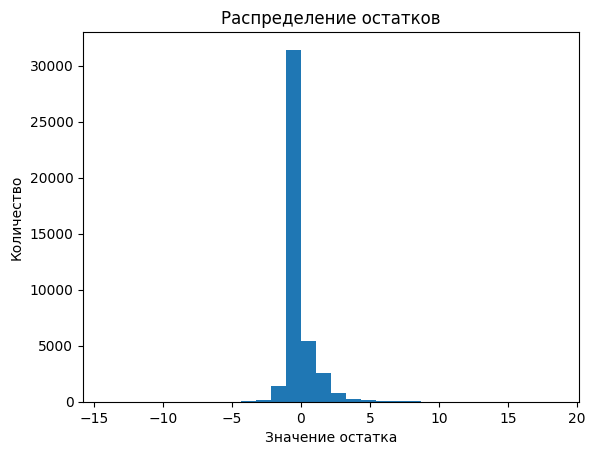

In [22]:
from scipy.stats import kstest

p = best_model.predict(X_train_const[best_features])
residuals = (y_train - p) / np.sqrt(p * (1 - p))

residuals_std = (residuals - residuals.mean()) / residuals.std()
ks_stat, ks_pvalue = kstest(residuals_std, 'norm')

plt.hist(residuals, bins=30)
plt.xlabel("Значение остатка")
plt.ylabel("Количество")
plt.title("Распределение остатков")

print("КС-статистика:", ks_stat)
print("p-value:", ks_pvalue)

Так как p-value < 0.05, H0 отклоняется -- остатки не распределены нормально.

### Решение проблемы дисбаланса классов
Как было отмечено, модели хорошо предсказывают отсутствие дождя, но плохо справляются с его наличием. 
Попробуем применить методы Undersampling и Oversampling. Обучим лучшую модель (probit) на измененных данных.

c:\Projects\ml-uust\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Projects\ml-uust\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


=============undersampling=============
Sensitivity (Полнота для 'Дождь будет'): 0.779
Specificity (Точность для 'Дождя не будет'): 0.812
AUC: 0.883



c:\Projects\ml-uust\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Projects\ml-uust\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


=============oversampling=============
Sensitivity (Полнота для 'Дождь будет'): 0.773
Specificity (Точность для 'Дождя не будет'): 0.816
AUC: 0.883



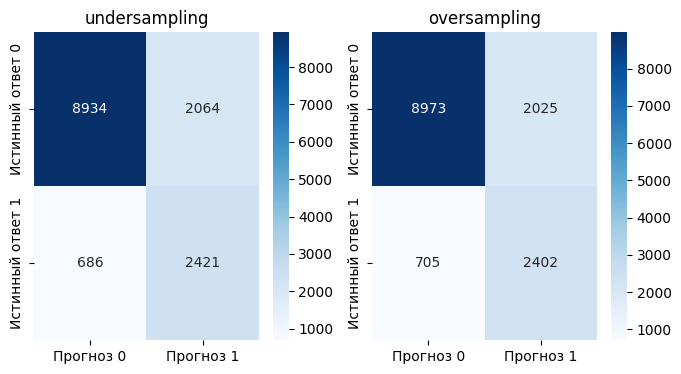

In [23]:
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler


res_sampling = {}

# Undersampling
rus = RandomUnderSampler(random_state=42)
X_resampled_under, y_resampled_under = rus.fit_resample(X_train, y_train)

# Oversampling (SMOTE)
smote = SMOTE(random_state=42)
X_resampled_over, y_resampled_over = smote.fit_resample(X_train, y_train)

sampling_methods = {
    "undersampling": (X_resampled_under, y_resampled_under),
    "oversampling": (X_resampled_over, y_resampled_over)
}


fig, axe = plt.subplots(1, 2, figsize=(8, 4))
i = 0


for name, (X_res, y_res) in sampling_methods.items():
    X_res_const = sm.add_constant(X_res)
    
    model, X_selected = stepwise_regression(X_res_const, y_res, model_type="probit")
    
    X_test_sel = X_test_const[X_selected.columns]
    y_pred_prob = model.predict(X_test_sel)
    y_pred = (y_pred_prob > 0.5).astype(int)
    
    auc = roc_auc_score(y_test, y_pred_prob)
    acc = accuracy_score(y_test, y_pred)
    conf_matr = confusion_matrix(y_test, y_pred)
    
    sns.heatmap(conf_matr, annot=True, fmt='d', cmap='Blues',
                xticklabels=["Прогноз 0", "Прогноз 1"],
                yticklabels=["Истинный ответ 0", "Истинный ответ 1"], ax=axe[i])
    axe[i].set_title(name)
    i += 1
    
    tn, fp, fn, tp = conf_matr.ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    
    res_sampling[name] = {
        "Accuracy": acc,
        "Sensitivity (TPR)": sensitivity,
        "Specificity (TNR)": specificity,
        "AUC": auc,
        "Gini": 2 * auc - 1
    }
    
    print(f"============={name}=============")
    print(f"Sensitivity (Полнота для 'Дождь будет'): {sensitivity:.3f}")
    print(f"Specificity (Точность для 'Дождя не будет'): {specificity:.3f}")
    print(f"AUC: {auc:.3f}\n")

Одна и та же архитектура модели показала схожие результаты на данных, сбалансированных разными способами.

Теперь модель более чем в 3 раза чаще ошибается на истинных отрицательных метках классов, но таких объектов больше в выборке примерно в 3 раза.

Сравнение результатов балансировки классов

In [24]:
comparison_sampling = pd.DataFrame(res_sampling).T

original_probit = comparison.loc[['probit']]
final_comparison = pd.concat([original_probit, comparison_sampling])

final_comparison[['Accuracy', 'Sensitivity (TPR)', 'Specificity (TNR)', 'AUC']]

,Accuracy,Sensitivity (TPR),Specificity (TNR),AUC
probit,0.854094,0.522691,0.947718,0.882887
undersampling,0.805034,0.779208,0.812330,0.882910
oversampling,0.806452,0.773093,0.815876,0.882507


Точность модели упала на 5, специфичность -- на 13%, зато чувствительность повысилась на 26%. Теперь модель лучше предсказывает редкое сообытие появления дождя. Метрика AUC при этом заметно не изменилась.

### Статистическая проверка гипотез для сбалансированных моделей
Проведем аналогичные тесты (LR, Хосмер-Лемшоу, КС-тест) для моделей с Undersampling и SMOTE.

Гипотезы:

- Тест отношения правдоподобия LR

    `H0`: Модель не является значимой

    `H1`: Модель значима

- Тест Хосмера-Лемшоу

    `H0`: Модель хорошо откалибрована и достаточно точно описывает данные.

    `H1`: Модель плохо откалибрована.

- Тест на нормальность (Колмогорова-Смирнова)

    `H0`: Распределение остатков согласовано с нормальным распределением

    `H1`: Распределение остатков не согласовано с нормальным распределением

In [25]:
from scipy.stats import chi2, kstest

def run_hypothesis_tests(model, X_train_set, y_train_set, name):
    print(f"\n{'='*20} ТЕСТЫ ДЛЯ МОДЕЛИ: {name} {'='*20}")
    
    # 1. McFadden R2
    llf = model.llf
    llnull = model.llnull
    mcfadden_r2 = 1 - (llf / llnull)
    print(f"McFadden R²: {mcfadden_r2:.4f}")

    # 2. LR-тест
    lr_stat = -2 * (llnull - llf)
    df_lr = model.df_model
    p_value_lr = chi2.sf(lr_stat, df_lr)
    print(f"LR статистика: {lr_stat:.2f}, p-value: {p_value_lr:.4e}")
    if p_value_lr < 0.05:
        print("Результат: Модель значима (H0 отклонена).")
    else:
        print("Результат: Модель не значима.")

    # 3. Тест Хосмера-Лемшоу (Калибровка)
    X_selected = X_train_set[model.params.index]
    y_prob = model.predict(X_selected)
    
    hl_df = pd.DataFrame({'y': y_train_set, 'prob': y_prob})
    hl_df['group'] = pd.qcut(hl_df['prob'], 10, duplicates='drop')
    
    obs = hl_df.groupby('group')['y'].sum()
    exp = hl_df.groupby('group')['prob'].sum()
    n_group = hl_df.groupby('group')['y'].count()
    
    hl_stat = (((obs - exp) ** 2) / (exp * (1 - exp / n_group))).sum()
    df_hl = len(obs) - 2
    p_value_hl = chi2.sf(hl_stat, df_hl)
    print(f"Статистика Хосмера-Лемшоу: {hl_stat:.2f}, p-value: {p_value_hl:.4f}")
    if p_value_hl > 0.05:
        print("Результат: Модель хорошо описывает данные (H0 подтверждена).")
    else:
        print("Результат: Модель плохо откалибрована (H0 отклонена).")

    # 4. Тест Колмогорова-Смирнова (Нормальность остатков)
    p = y_prob

    residuals = (y_train_set - p) / np.sqrt(p * (1 - p))
    residuals_std = (residuals - residuals.mean()) / residuals.std()
    ks_stat, ks_pvalue = kstest(residuals_std, 'norm')
    
    print(f"КС-статистика: {ks_stat:.4f}, p-value: {ks_pvalue:.4e}")
    if ks_pvalue > 0.05:
        print("Результат: Остатки распределены нормально (H0 подтверждена).")
    else:
        print("Результат: Остатки не распределены нормально (H0 отклонена).")

for name in sampling_methods.keys():
    X_res, y_res = sampling_methods[name]
    X_res_const = sm.add_constant(X_res)
    
    final_model, _ = stepwise_regression(X_res_const, y_res, model_type="probit")
    
    run_hypothesis_tests(final_model, X_res_const, y_res, name)

c:\Projects\ml-uust\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Projects\ml-uust\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "



==================== ТЕСТЫ ДЛЯ МОДЕЛИ: undersampling ====================
McFadden R²: 0.3809
LR статистика: 9842.21, p-value: 0.0000e+00
Результат: Модель значима (H0 отклонена).
Статистика Хосмера-Лемшоу: 39.37, p-value: 0.0000
Результат: Модель плохо откалибрована (H0 отклонена).
КС-статистика: 0.0992, p-value: 5.0938e-160
Результат: Остатки не распределены нормально (H0 отклонена).


c:\Projects\ml-uust\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Projects\ml-uust\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "



==================== ТЕСТЫ ДЛЯ МОДЕЛИ: oversampling ====================
McFadden R²: 0.3951
LR статистика: 36144.30, p-value: 0.0000e+00
Результат: Модель значима (H0 отклонена).
Статистика Хосмера-Лемшоу: 197.96, p-value: 0.0000
Результат: Модель плохо откалибрована (H0 отклонена).
КС-статистика: 0.1066, p-value: 0.0000e+00
Результат: Остатки не распределены нормально (H0 отклонена).


### Вывод

В ходе работы для задачи предсказания дождя были построены 3 модели логистической регрессии: на основе функций нормального, логистического и экстремального распределений. По критериям информативности и точности бинарной классификации наилучшей оказалась модель probit с долей верных положительных ответов (дождь будет) 54% и отрицательных (дождя не будет) 94%.

Согласно маржинальным коэффициентам наиболее значимыми для предсказания осадков являются признаки Скорость сильнейшего за сутки порыва ветра, Максимальная температура воздуха, атмосферное давление утром, солнечность.

Качество подгонки моделей по критерию $R^2$ оказалось низким (0.36). Тест отношения правдоподобия показал, что результаты модели являются значимыми. Тест Колмогорова-Смирнова и графический тест на нормальность показали, что остатки не соответствуют нормальному распределению.